# Marketing Mix Modeling with Google Meridian
## Marketing Analytics Final Project
### Project Objective

The objective of this project is to evaluate the effectiveness of different marketing channels using Marketing Mix Modeling (MMM). Google Meridian is used to estimate the contribution of each marketing channel to total purchases, analyze return on investment (ROI), evaluate diminishing returns, and simulate marketing budget allocation scenarios. SHAP is also applied to improve the interpretability of the model predictions.

# 1. Data Preparation

## 1.1 Import Libraries

The first step is to import all the Python libraries required for data manipulation, visualization, exploratory data analysis, and Marketing Mix Modeling. Google Meridian will be used as the primary framework for building the Marketing Mix Model, while SHAP will be used to explain the model predictions.

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Missing value visualization
import missingno as msno

# Explainability
import shap

# Google Meridian
import meridian
from meridian.analysis import analyzer
from meridian.analysis import visualizer
from meridian.data import data_frame_input_data_builder
from meridian.model import model

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

### Verify Google Meridian Installation

Before loading the dataset, we verify that Google Meridian has been installed correctly. This confirms that all required modules are available and that the environment is ready for Marketing Mix Modeling.

In [306]:
print("Google Meridian Version:", meridian.__version__)
print("Status: Google Meridian loaded successfully.")

Google Meridian Version: 1.7.0
Status: Google Meridian loaded successfully.


## 1.2 Load the Dataset

The Conjura Marketing Mix Modeling dataset is loaded into a pandas DataFrame. This step allows us to inspect the dataset structure before performing exploratory data analysis and preparing the data for modeling.

In [307]:
df = pd.read_csv("../data/conjura_mmm_data.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


#### Display the First Five Rows

In [308]:
df.head()

,MMM_TIMESERIES_ID,ORGANISATION_ID,ORGANISATION_VERTICAL,ORGANISATION_SUBVERTICAL,ORGANISATION_MARKETING_SOURCES,ORGANISATION_PRIMARY_TERRITORY_NAME,TERRITORY_NAME,DATE_DAY,CURRENCY_CODE,FIRST_PURCHASES,...,META_FACEBOOK_IMPRESSIONS,META_INSTAGRAM_IMPRESSIONS,META_OTHER_IMPRESSIONS,TIKTOK_IMPRESSIONS,DIRECT_CLICKS,BRANDED_SEARCH_CLICKS,ORGANIC_SEARCH_CLICKS,EMAIL_CLICKS,REFERRAL_CLICKS,ALL_OTHER_CLICKS
0,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,2022-07-29,USD,22,...,18997.0,NaN,NaN,NaN,139.0,NaN,300.0,1.0,61.0,40.0
1,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,2022-07-30,USD,14,...,20188.0,NaN,NaN,NaN,209.0,NaN,442.0,8.0,110.0,62.0
2,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,2022-07-31,USD,31,...,24718.0,NaN,NaN,NaN,262.0,NaN,427.0,631.0,108.0,65.0
3,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,2022-08-01,USD,18,...,25076.0,NaN,NaN,NaN,247.0,NaN,400.0,117.0,125.0,68.0
4,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,2022-08-02,USD,23,...,22688.0,NaN,NaN,NaN,255.0,NaN,425.0,37.0,146.0,65.0


### Interpretation of the Dataset Preview

The dataset has been loaded successfully. The first five observations confirm that the data contains information about purchases, marketing spend, impressions, clicks, organizational details, and dates. These variables will be explored further to understand their relationships before building the Marketing Mix Model.

# 2. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the structure, quality, and characteristics of the dataset before building the Marketing Mix Model. This includes examining the dataset dimensions, variable types, missing values, summary statistics, and relationships between marketing variables and purchases.

## 2.1 Dataset Dimensions

In [309]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 132759
Number of columns: 50


### Interpretation

The dataset contains **132,759 observations** and **50 variables**, providing a large amount of information for analyzing marketing performance. The size of the dataset is sufficient for building a robust Marketing Mix Model and evaluating the contribution of multiple marketing channels.

#### Display Column Names

In [310]:
df.columns.tolist()

['MMM_TIMESERIES_ID',
 'ORGANISATION_ID',
 'ORGANISATION_VERTICAL',
 'ORGANISATION_SUBVERTICAL',
 'ORGANISATION_MARKETING_SOURCES',
 'ORGANISATION_PRIMARY_TERRITORY_NAME',
 'TERRITORY_NAME',
 'DATE_DAY',
 'CURRENCY_CODE',
 'FIRST_PURCHASES',
 'FIRST_PURCHASES_UNITS',
 'FIRST_PURCHASES_ORIGINAL_PRICE',
 'FIRST_PURCHASES_GROSS_DISCOUNT',
 'ALL_PURCHASES',
 'ALL_PURCHASES_UNITS',
 'ALL_PURCHASES_ORIGINAL_PRICE',
 'ALL_PURCHASES_GROSS_DISCOUNT',
 'GOOGLE_PAID_SEARCH_SPEND',
 'GOOGLE_SHOPPING_SPEND',
 'GOOGLE_PMAX_SPEND',
 'GOOGLE_DISPLAY_SPEND',
 'GOOGLE_VIDEO_SPEND',
 'META_FACEBOOK_SPEND',
 'META_INSTAGRAM_SPEND',
 'META_OTHER_SPEND',
 'TIKTOK_SPEND',
 'GOOGLE_PAID_SEARCH_CLICKS',
 'GOOGLE_SHOPPING_CLICKS',
 'GOOGLE_PMAX_CLICKS',
 'GOOGLE_DISPLAY_CLICKS',
 'GOOGLE_VIDEO_CLICKS',
 'META_FACEBOOK_CLICKS',
 'META_INSTAGRAM_CLICKS',
 'META_OTHER_CLICKS',
 'TIKTOK_CLICKS',
 'GOOGLE_PAID_SEARCH_IMPRESSIONS',
 'GOOGLE_SHOPPING_IMPRESSIONS',
 'GOOGLE_PMAX_IMPRESSIONS',
 'GOOGLE_DISPLAY_IMPRESSIO

### Interpretation

The dataset contains variables describing organizational information, purchases, marketing spend, impressions, clicks, and dates. These variables provide the necessary inputs for exploratory analysis and Marketing Mix Modeling.

## 2.2 Dataset Information

Understanding the data types and completeness of each variable is an important first step before data preprocessing. The `info()` function provides information about the number of observations, non-null values, memory usage, and data types of each variable.

In [311]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132759 entries, 0 to 132758
Data columns (total 50 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   MMM_TIMESERIES_ID                    132759 non-null  object 
 1   ORGANISATION_ID                      132759 non-null  object 
 2   ORGANISATION_VERTICAL                124649 non-null  object 
 3   ORGANISATION_SUBVERTICAL             124649 non-null  object 
 4   ORGANISATION_MARKETING_SOURCES       132759 non-null  object 
 5   ORGANISATION_PRIMARY_TERRITORY_NAME  132759 non-null  object 
 6   TERRITORY_NAME                       132759 non-null  object 
 7   DATE_DAY                             132759 non-null  object 
 8   CURRENCY_CODE                        132759 non-null  object 
 9   FIRST_PURCHASES                      132759 non-null  int64  
 10  FIRST_PURCHASES_UNITS                132759 non-null  int64  
 11  FIRST_PURCHAS

### Interpretation

The dataset contains a combination of numerical and categorical variables. Numerical variables mainly represent purchases, marketing spend, impressions, and clicks, while categorical variables describe organizational information and dates. The output also highlights that several marketing variables contain missing values, which will need to be addressed before building the Marketing Mix Model.

## 2.3 Summary Statistics

Summary statistics provide an overview of the numerical variables by reporting measures such as the mean, standard deviation, minimum, maximum, and quartiles. These statistics help identify the scale of the variables and detect potential outliers.

In [312]:
df.describe()

,FIRST_PURCHASES,FIRST_PURCHASES_UNITS,FIRST_PURCHASES_ORIGINAL_PRICE,FIRST_PURCHASES_GROSS_DISCOUNT,ALL_PURCHASES,ALL_PURCHASES_UNITS,ALL_PURCHASES_ORIGINAL_PRICE,ALL_PURCHASES_GROSS_DISCOUNT,GOOGLE_PAID_SEARCH_SPEND,GOOGLE_SHOPPING_SPEND,...,META_FACEBOOK_IMPRESSIONS,META_INSTAGRAM_IMPRESSIONS,META_OTHER_IMPRESSIONS,TIKTOK_IMPRESSIONS,DIRECT_CLICKS,BRANDED_SEARCH_CLICKS,ORGANIC_SEARCH_CLICKS,EMAIL_CLICKS,REFERRAL_CLICKS,ALL_OTHER_CLICKS
count,132759.000000,1.327590e+05,1.327590e+05,1.327590e+05,132759.000000,1.327590e+05,1.327590e+05,1.327590e+05,96637.000000,78980.000000,...,8.011200e+04,2.681700e+04,2.354500e+04,3462.000000,98541.000000,88825.000000,122702.000000,118663.000000,121737.000000,121778.000000
mean,83.857599,5.193310e+02,6.462644e+04,5.094456e+03,124.536845,1.291123e+03,1.186526e+05,1.215327e+04,416.082224,837.683294,...,9.754821e+04,6.584053e+04,1.724004e+03,43198.584922,580.888473,309.502449,569.754218,357.539284,255.566106,680.092472
std,345.347969,5.033012e+03,6.148369e+05,5.541766e+04,1496.001905,1.291308e+04,1.211315e+06,1.395501e+05,2519.605821,3628.118892,...,1.846109e+05,1.273965e+05,2.913215e+04,58713.550984,1046.358097,670.680758,1190.888629,944.721232,817.485088,2331.667413
min,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,1.000000e+00,3.490000e+00,0.000000e+00,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,14.000000,2.400000e+01,1.709675e+03,4.050000e+01,19.000000,3.400000e+01,2.546000e+03,6.994500e+01,15.240000,61.330000,...,9.420750e+03,3.400000e+03,1.300000e+01,4042.250000,93.000000,38.000000,94.000000,20.000000,19.000000,69.000000
50%,33.000000,6.600000e+01,5.262000e+03,1.950000e+02,49.000000,1.060000e+02,7.542000e+03,3.137500e+02,61.400000,245.950000,...,3.065900e+04,1.956700e+04,7.800000e+01,16886.000000,236.000000,116.000000,217.000000,72.000000,58.000000,205.000000
75%,98.000000,2.000000e+02,1.622458e+04,8.570809e+02,141.000000,3.130000e+02,2.319457e+04,1.277665e+03,198.150000,878.360000,...,9.323125e+04,5.888800e+04,4.360000e+02,63467.250000,653.000000,269.000000,574.000000,306.000000,171.000000,572.000000
max,96010.000000,1.000404e+06,7.212126e+07,5.840348e+06,426403.000000,1.000922e+06,1.308895e+08,1.522848e+07,165661.940000,615988.530000,...,3.686852e+06,2.603035e+06,1.325133e+06,349275.000000,29561.000000,22974.000000,125421.000000,46997.000000,32221.000000,298560.000000


### Interpretation

The summary statistics indicate considerable variation across the marketing and purchase variables. Some variables exhibit extremely large maximum values compared to their median values, suggesting the presence of outliers or periods of unusually high marketing activity. This behavior is common in marketing datasets due to promotional campaigns and seasonal effects.

## 2.4 Missing Values Analysis

Missing values are common in marketing datasets because not every marketing channel is active at all times. Identifying the amount and distribution of missing values helps determine the appropriate preprocessing strategy before model development.

In [313]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

missing

TIKTOK_SPEND                      129297
TIKTOK_IMPRESSIONS                129297
TIKTOK_CLICKS                     129297
GOOGLE_VIDEO_CLICKS               125131
GOOGLE_VIDEO_SPEND                125131
GOOGLE_VIDEO_IMPRESSIONS          125131
GOOGLE_DISPLAY_CLICKS             114013
GOOGLE_DISPLAY_IMPRESSIONS        114013
GOOGLE_DISPLAY_SPEND              114013
META_OTHER_CLICKS                 109214
META_OTHER_SPEND                  109214
META_OTHER_IMPRESSIONS            109214
META_INSTAGRAM_SPEND              105942
META_INSTAGRAM_CLICKS             105942
META_INSTAGRAM_IMPRESSIONS        105942
GOOGLE_PMAX_SPEND                  71633
GOOGLE_PMAX_IMPRESSIONS            71633
GOOGLE_PMAX_CLICKS                 71633
GOOGLE_SHOPPING_IMPRESSIONS        53779
GOOGLE_SHOPPING_SPEND              53779
GOOGLE_SHOPPING_CLICKS             53779
META_FACEBOOK_CLICKS               52647
META_FACEBOOK_IMPRESSIONS          52647
META_FACEBOOK_SPEND                52647
BRANDED_SEARCH_C

### Interpretation

Several marketing variables contain missing values. This is expected because some marketing channels were not active throughout the entire observation period. These missing values will be handled appropriately during the data preparation stage before fitting the Marketing Mix Model.

#### Missing Values Visualization

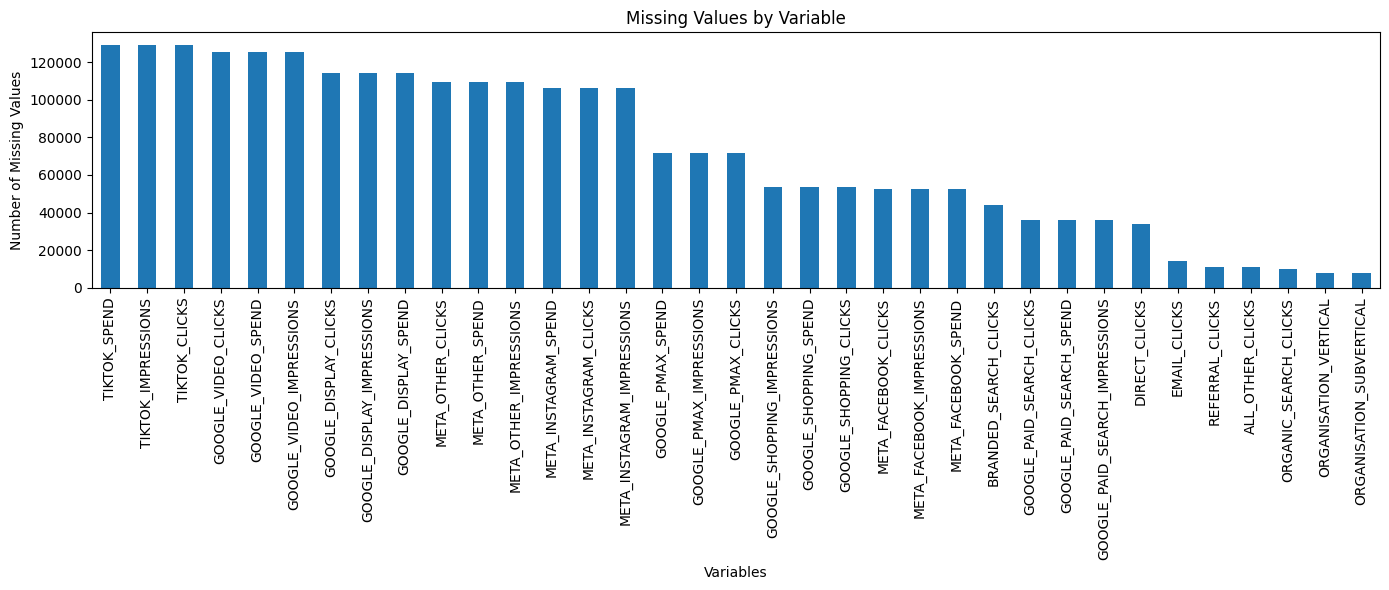

In [314]:
plt.figure(figsize=(14,6))

missing.plot(kind="bar")

plt.title("Missing Values by Variable")
plt.xlabel("Variables")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

### Interpretation

The visualization clearly shows that some advertising channels contain substantially more missing observations than others. This pattern reflects differences in campaign availability rather than data collection errors. Understanding these missing values is essential before preparing the dataset for Marketing Mix Modeling.

## 2.5 Daily Purchases Trend

Understanding how purchases evolve over time helps identify seasonal patterns, promotional periods, and unusual spikes that may influence marketing effectiveness.

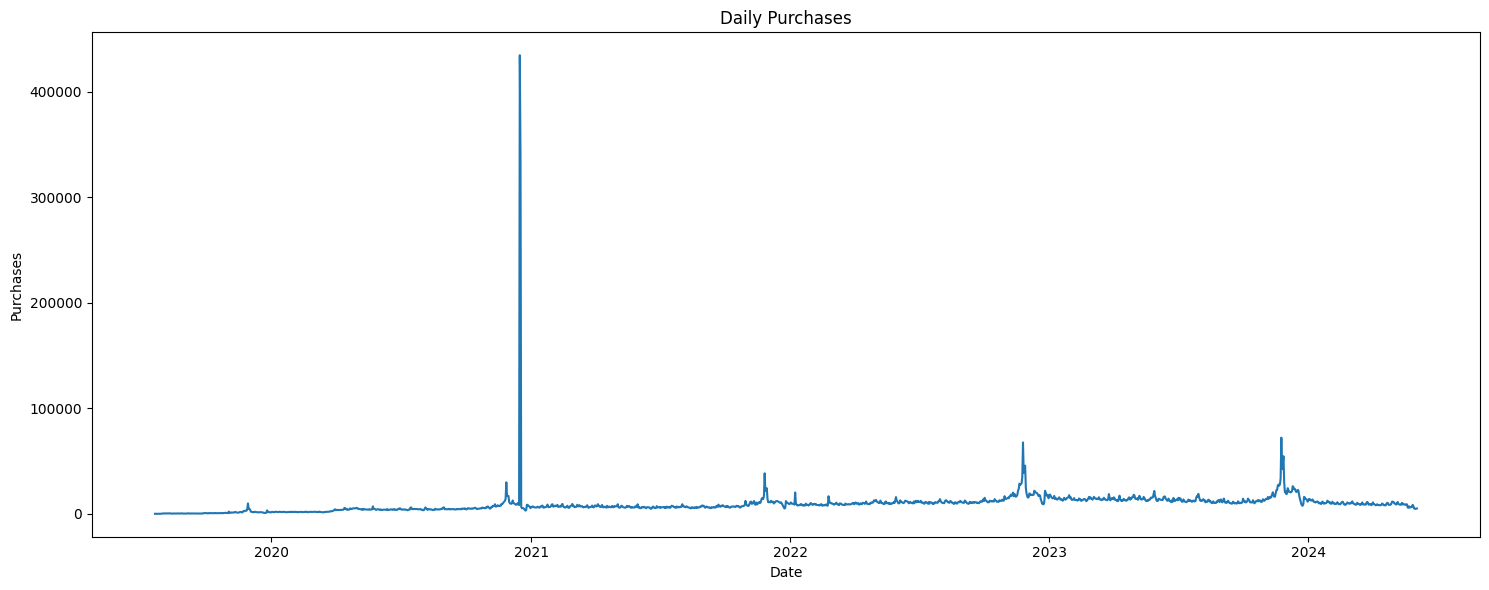

In [315]:
df["DATE_DAY"] = pd.to_datetime(df["DATE_DAY"])

daily_sales = (
    df.groupby("DATE_DAY")["ALL_PURCHASES"]
      .sum()
)

plt.figure(figsize=(15,6))

plt.plot(daily_sales)

plt.title("Daily Purchases")
plt.xlabel("Date")
plt.ylabel("Purchases")

plt.tight_layout()

plt.show()

### Interpretation

The purchases exhibit clear fluctuations over time, with several noticeable peaks indicating periods of unusually high customer demand. These spikes are likely associated with promotional campaigns, seasonal events, or special marketing activities that will be investigated further through Marketing Mix Modeling.

## 2.6 Marketing Spend Trends

Marketing spend is analyzed over time to understand how investment varies across advertising channels. This visualization provides an initial understanding of campaign intensity and budget allocation.

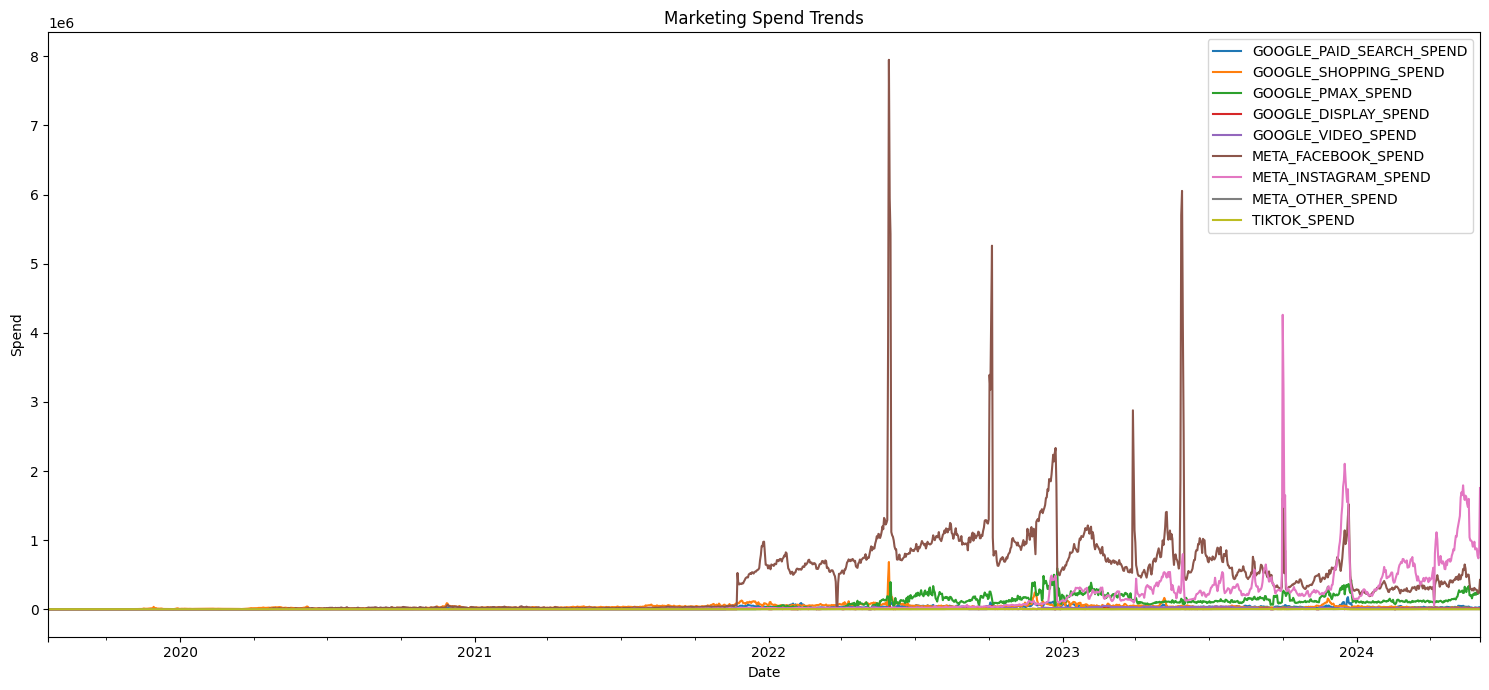

In [316]:
spend_columns = [col for col in df.columns if "SPEND" in col]

daily_spend = (
    df.groupby("DATE_DAY")[spend_columns]
      .sum()
)

daily_spend.plot(figsize=(15,7))

plt.title("Marketing Spend Trends")
plt.xlabel("Date")
plt.ylabel("Spend")

plt.tight_layout()

plt.show()

### Interpretation

Marketing investment differs substantially across channels and across time. Some channels receive consistently higher spending, while others are used only during specific campaigns. These spending patterns will help estimate the contribution of each channel in the Marketing Mix Model.

## 2.7 Correlation Analysis

Correlation analysis helps identify relationships between numerical variables. Understanding these relationships provides insight into how marketing spend, impressions, clicks, and purchases move together before fitting the Marketing Mix Model.

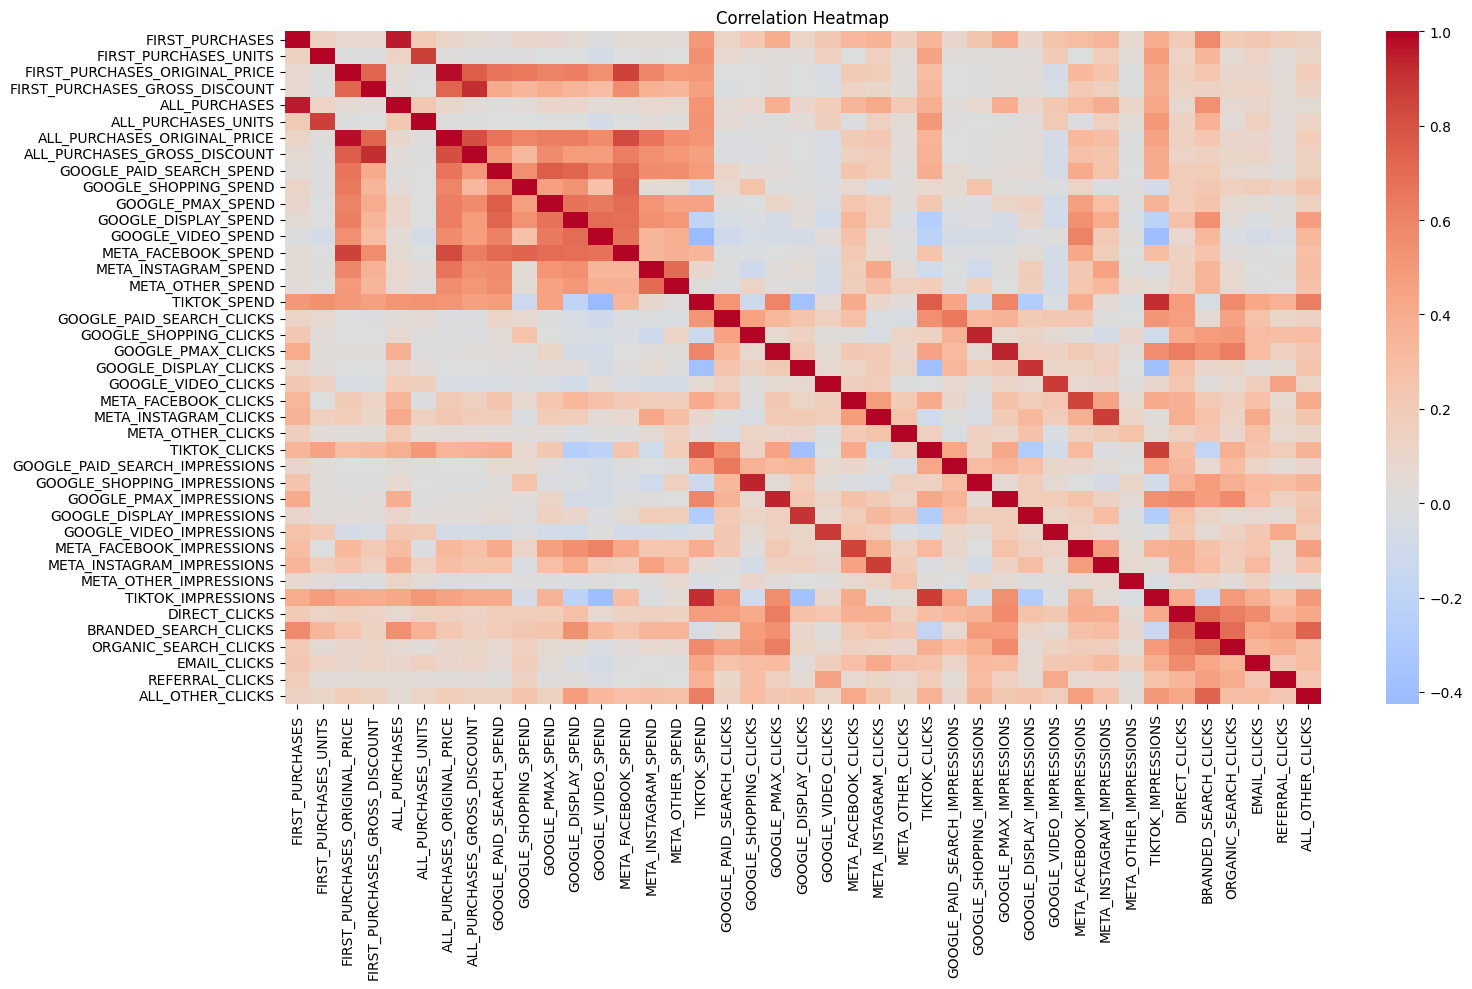

In [317]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(16,10))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

### Interpretation

The correlation heatmap provides an overview of the linear relationships between numerical variables. Positive correlations suggest variables that tend to increase together, while negative correlations indicate inverse relationships. These insights are useful for understanding interactions between marketing activities and purchase outcomes before model development.

## 2.8 Distribution of Purchases

The distribution of purchases helps identify skewness, variability, and the presence of unusually large purchase values that may influence the Marketing Mix Model.

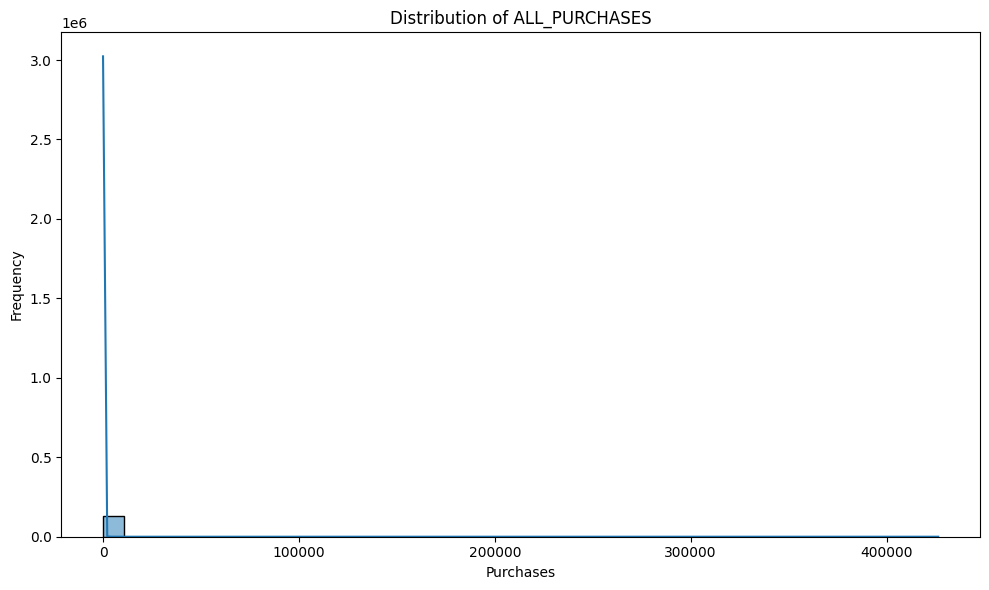

In [318]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["ALL_PURCHASES"],
    bins=40,
    kde=True
)

plt.title("Distribution of ALL_PURCHASES")

plt.xlabel("Purchases")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

### Interpretation

The distribution of purchases is not perfectly symmetric, indicating that some days experience substantially higher purchase volumes than others. Such behaviour is common in marketing datasets due to promotions, seasonal events, and fluctuations in advertising activity.

# 3. Data Preparation

The objective of this section is to prepare the dataset for Marketing Mix Modeling using Google Meridian. This involves handling missing values, selecting the target variable, creating time-based features, identifying media channels and control variables, and constructing the final modeling dataset.

## 3.1 — Make a Working Copy

In [319]:
mmm_df = df.copy()

print("Working dataset created successfully.")

Working dataset created successfully.


### Interpretation

A copy of the original dataset has been created to preserve the raw data. All preprocessing and feature engineering steps will be performed on this working dataset.

## 3.2 Handle Missing Values

#### Identify Marketing Spend Variables

In [320]:
spend_columns = [col for col in mmm_df.columns if "SPEND" in col]

print("Marketing Spend Variables:")
print(spend_columns)

Marketing Spend Variables:
['GOOGLE_PAID_SEARCH_SPEND', 'GOOGLE_SHOPPING_SPEND', 'GOOGLE_PMAX_SPEND', 'GOOGLE_DISPLAY_SPEND', 'GOOGLE_VIDEO_SPEND', 'META_FACEBOOK_SPEND', 'META_INSTAGRAM_SPEND', 'META_OTHER_SPEND', 'TIKTOK_SPEND']


#### Replace Missing Spend Values

In [321]:
mmm_df[spend_columns] = mmm_df[spend_columns].fillna(0)

print("Missing spend values replaced with 0.")

Missing spend values replaced with 0.


### Interpretation

Missing values in the marketing spend variables were replaced with zero. In Marketing Mix Modeling, a missing spend value generally indicates that no advertising budget was allocated to that channel on that day rather than missing information.

## 3.3 — Check Remaining Missing Values

In [322]:
remaining_missing = mmm_df[spend_columns].isnull().sum()

remaining_missing

GOOGLE_PAID_SEARCH_SPEND    0
GOOGLE_SHOPPING_SPEND       0
GOOGLE_PMAX_SPEND           0
GOOGLE_DISPLAY_SPEND        0
GOOGLE_VIDEO_SPEND          0
META_FACEBOOK_SPEND         0
META_INSTAGRAM_SPEND        0
META_OTHER_SPEND            0
TIKTOK_SPEND                0
dtype: int64

### Interpretation

After preprocessing, all marketing spend variables are free of missing values and are ready for model development.

## 3.4 Date Conversion

The date variable is converted into the datetime format to enable time-based feature engineering and chronological analysis. This is required for Marketing Mix Modeling because advertising effectiveness is analyzed over time.

#### Convert Date Column

In [323]:
mmm_df["DATE_DAY"] = pd.to_datetime(mmm_df["DATE_DAY"])

print(mmm_df["DATE_DAY"].dtype)

datetime64[ns]


### Interpretation

The date variable has been successfully converted into datetime format, allowing chronological sorting, feature engineering, and time-series analysis.

## 3.5 Feature Engineering

Additional time-based variables are created to capture seasonality and temporal patterns that may influence purchases independently of advertising activities.

In [324]:
mmm_df["YEAR"] = mmm_df["DATE_DAY"].dt.year
mmm_df["MONTH"] = mmm_df["DATE_DAY"].dt.month
mmm_df["DAY_OF_WEEK"] = mmm_df["DATE_DAY"].dt.day_name()

print("Time features created successfully.")

Time features created successfully.


### Interpretation

Three time-based features were created:

- **YEAR** captures long-term changes over time.
- **MONTH** captures seasonal effects.
- **DAY_OF_WEEK** captures weekly purchasing patterns.

These variables can later be used as control variables in the Marketing Mix Model.

## 3.6 Define Modeling Variables

The Marketing Mix Model requires three categories of variables:

- **Target Variable** – the business outcome to be predicted.
- **Media Variables** – advertising channels whose effectiveness will be estimated.
- **Control Variables** – variables that explain purchasing behaviour beyond advertising, such as seasonality and long-term trends.

In [325]:
mmm_df[["DATE_DAY", "YEAR", "MONTH", "DAY_OF_WEEK"]].head()

,DATE_DAY,YEAR,MONTH,DAY_OF_WEEK
0,2022-07-29,2022,7,Friday
1,2022-07-30,2022,7,Saturday
2,2022-07-31,2022,7,Sunday
3,2022-08-01,2022,8,Monday
4,2022-08-02,2022,8,Tuesday


### Interpretation

The newly created time variables appear correctly and will support the modeling process by accounting for seasonal and weekly variations in purchasing behavior.

### Target Variable

The target variable represents the business outcome that the Marketing Mix Model aims to explain. For this project, **ALL_PURCHASES** is selected as the response variable because it reflects the total number of purchases generated each day.

In [326]:
target_variable = "ALL_PURCHASES"

### Interpretation

The **ALL_PURCHASES** variable has been selected as the response variable. Google Meridian will estimate how different marketing channels contribute to daily purchases.

### Define Media Variables

Media variables represent the daily advertising expenditure across different marketing channels. These variables are the primary inputs used by Google Meridian to estimate marketing effectiveness and return on investment.

In [327]:
media_variables = [
    "GOOGLE_PAID_SEARCH_SPEND",
    "GOOGLE_SHOPPING_SPEND",
    "GOOGLE_PMAX_SPEND",
    "GOOGLE_DISPLAY_SPEND"
]

print(media_variables)

['GOOGLE_PAID_SEARCH_SPEND', 'GOOGLE_SHOPPING_SPEND', 'GOOGLE_PMAX_SPEND', 'GOOGLE_DISPLAY_SPEND']


### Interpretation

Four active paid marketing channels were selected as media variables after excluding inactive channels with no meaningful advertising activity. These variables were used to estimate the contribution of marketing spend to purchases.

### Control Variables

Control variables capture external factors and seasonal patterns that may influence purchases independently of marketing activities. Including these variables improves the accuracy of the Marketing Mix Model.

In [328]:
control_variables = [
    "YEAR",
    "MONTH"
]

print(control_variables)

['YEAR', 'MONTH']


### Interpretation

The **YEAR** and **MONTH** variables are included as control variables to account for long-term trends and seasonal effects that may influence purchasing behaviour.

## 3.7 Create the Modeling Dataset

A dedicated modeling dataset is created by combining the date, target variable, media variables, and control variables. This dataset will be used as the input for Google Meridian.

In [329]:
model_df = mmm_df[
    ["DATE_DAY", target_variable] +
    media_variables +
    control_variables
].copy()

print(model_df.head())

    DATE_DAY  ALL_PURCHASES  GOOGLE_PAID_SEARCH_SPEND  GOOGLE_SHOPPING_SPEND  \
0 2022-07-29             27                      0.00                    0.0   
1 2022-07-30             17                      0.00                    0.0   
2 2022-07-31             39                      0.00                    0.0   
3 2022-08-01             22                     35.24                    0.0   
4 2022-08-02             28                     38.40                    0.0   

   GOOGLE_PMAX_SPEND  GOOGLE_DISPLAY_SPEND  YEAR  MONTH  
0         205.528905                   0.0  2022      7  
1         277.082025                   0.0  2022      7  
2         427.436429                   0.0  2022      7  
3         347.232798                   0.0  2022      8  
4         314.952971                   0.0  2022      8  


### Interpretation

The modeling dataset contains all variables required for Marketing Mix Modeling, including the response variable, media channels, and control variables. This structured dataset is now ready for conversion into the Google Meridian input format.

## 3.8 Verify the Modeling Dataset

The structure of the modeling dataset is verified to ensure that all required variables are present and correctly formatted before model development.

#### Verify Dataset Structure

In [330]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132759 entries, 0 to 132758
Data columns (total 8 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   DATE_DAY                  132759 non-null  datetime64[ns]
 1   ALL_PURCHASES             132759 non-null  int64         
 2   GOOGLE_PAID_SEARCH_SPEND  132759 non-null  float64       
 3   GOOGLE_SHOPPING_SPEND     132759 non-null  float64       
 4   GOOGLE_PMAX_SPEND         132759 non-null  float64       
 5   GOOGLE_DISPLAY_SPEND      132759 non-null  float64       
 6   YEAR                      132759 non-null  int32         
 7   MONTH                     132759 non-null  int32         
dtypes: datetime64[ns](1), float64(4), int32(2), int64(1)
memory usage: 7.1 MB


#### Check Missing Values

In [331]:
model_df.isnull().sum()

DATE_DAY                    0
ALL_PURCHASES               0
GOOGLE_PAID_SEARCH_SPEND    0
GOOGLE_SHOPPING_SPEND       0
GOOGLE_PMAX_SPEND           0
GOOGLE_DISPLAY_SPEND        0
YEAR                        0
MONTH                       0
dtype: int64

### Interpretation

The modeling dataset has the expected structure and contains no missing values in the variables required for model development. It is now ready to be converted into the format expected by Google Meridian.

## 3.9 Create Final Modeling Dataset

The original dataset contains multiple observations for the same organization on the same day (e.g., different territories or marketing sources). Since Google Meridian requires one observation per geo per time period, the data is aggregated at the organisation-day level.

The aggregation follows the business logic:

- Purchases are summed.
- Marketing spend is summed across all channels.
- Click-based control variables are summed.
- Year and Month are retained from the observation date.

In [334]:
df["DATE_DAY"] = pd.to_datetime(df["DATE_DAY"])

df["YEAR"] = df["DATE_DAY"].dt.year
df["MONTH"] = df["DATE_DAY"].dt.month

In [335]:
# ============================================================
# Create Final Modeling Dataset
# ============================================================

model_df = df[
    [
        # Geo & Time
        "ORGANISATION_ID",
        "DATE_DAY",

        # Target Variable
        "ALL_PURCHASES",

        # ==========================
        # Media Spend Variables
        # ==========================
        "GOOGLE_PAID_SEARCH_SPEND",
        "GOOGLE_SHOPPING_SPEND",
        "GOOGLE_PMAX_SPEND",
        "GOOGLE_DISPLAY_SPEND",
        "GOOGLE_VIDEO_SPEND",
        "META_FACEBOOK_SPEND",
        "META_INSTAGRAM_SPEND",
        "META_OTHER_SPEND",
        "TIKTOK_SPEND",

        # ==========================
        # Media Exposure (Clicks)
        # ==========================
        "GOOGLE_PAID_SEARCH_CLICKS",
        "GOOGLE_SHOPPING_CLICKS",
        "GOOGLE_PMAX_CLICKS",
        "GOOGLE_DISPLAY_CLICKS",
        "GOOGLE_VIDEO_CLICKS",
        "META_FACEBOOK_CLICKS",
        "META_INSTAGRAM_CLICKS",
        "META_OTHER_CLICKS",
        "TIKTOK_CLICKS",

        # Controls
        "YEAR",
        "MONTH"
    ]
].copy()

print(model_df.shape)


# ============================================================
# Aggregate duplicate organisation-day observations
# ============================================================

aggregation = {
    "ALL_PURCHASES": "sum",

    "GOOGLE_PAID_SEARCH_SPEND": "sum",
    "GOOGLE_SHOPPING_SPEND": "sum",
    "GOOGLE_PMAX_SPEND": "sum",
    "GOOGLE_DISPLAY_SPEND": "sum",
    "GOOGLE_VIDEO_SPEND": "sum",
    "META_FACEBOOK_SPEND": "sum",
    "META_INSTAGRAM_SPEND": "sum",
    "META_OTHER_SPEND": "sum",
    "TIKTOK_SPEND": "sum",

    "GOOGLE_PAID_SEARCH_CLICKS": "sum",
    "GOOGLE_SHOPPING_CLICKS": "sum",
    "GOOGLE_PMAX_CLICKS": "sum",
    "GOOGLE_DISPLAY_CLICKS": "sum",
    "GOOGLE_VIDEO_CLICKS": "sum",
    "META_FACEBOOK_CLICKS": "sum",
    "META_INSTAGRAM_CLICKS": "sum",
    "META_OTHER_CLICKS": "sum",
    "TIKTOK_CLICKS": "sum",

    "YEAR": "first",
    "MONTH": "first"
}

model_df = (
    model_df
    .groupby(["ORGANISATION_ID", "DATE_DAY"], as_index=False)
    .agg(aggregation)
)

# Add a constant population value required by Meridian
model_df["population"] = 1

print("Final Modeling Dataset Shape:", model_df.shape)

model_df.head()

(132759, 23)
Final Modeling Dataset Shape: (84032, 24)


,ORGANISATION_ID,DATE_DAY,ALL_PURCHASES,GOOGLE_PAID_SEARCH_SPEND,GOOGLE_SHOPPING_SPEND,GOOGLE_PMAX_SPEND,GOOGLE_DISPLAY_SPEND,GOOGLE_VIDEO_SPEND,META_FACEBOOK_SPEND,META_INSTAGRAM_SPEND,...,GOOGLE_PMAX_CLICKS,GOOGLE_DISPLAY_CLICKS,GOOGLE_VIDEO_CLICKS,META_FACEBOOK_CLICKS,META_INSTAGRAM_CLICKS,META_OTHER_CLICKS,TIKTOK_CLICKS,YEAR,MONTH,population
0,04769dac8b828ec7a85676d9e2bffe6f,2022-07-29,27,0.00,0.0,205.528905,0.0,0.0,233.75,0.0,...,255.0,0.0,0.0,163.0,0.0,0.0,0.0,2022,7,1
1,04769dac8b828ec7a85676d9e2bffe6f,2022-07-30,17,0.00,0.0,277.082025,0.0,0.0,248.84,0.0,...,348.0,0.0,0.0,128.0,0.0,0.0,0.0,2022,7,1
2,04769dac8b828ec7a85676d9e2bffe6f,2022-07-31,39,0.00,0.0,427.436429,0.0,0.0,274.51,0.0,...,405.0,0.0,0.0,148.0,0.0,0.0,0.0,2022,7,1
3,04769dac8b828ec7a85676d9e2bffe6f,2022-08-01,22,35.24,0.0,347.232798,0.0,0.0,270.06,0.0,...,320.0,0.0,0.0,163.0,0.0,0.0,0.0,2022,8,1
4,04769dac8b828ec7a85676d9e2bffe6f,2022-08-02,28,38.40,0.0,314.952971,0.0,0.0,257.62,0.0,...,330.0,0.0,0.0,127.0,0.0,0.0,0.0,2022,8,1


## 3.10 Verify the Final Modeling Dataset

The modeling dataset is verified to ensure that each organisation has only one observation per day, satisfying the input requirements of the Google Meridian framework.

In [336]:
duplicates = model_df.groupby(
    ["ORGANISATION_ID", "DATE_DAY"]
).size().max()

print("Maximum duplicate observations:", duplicates)

print("\nNumber of organisations:",
      model_df["ORGANISATION_ID"].nunique())

print("\nFinal Dataset Shape:",
      model_df.shape)

Maximum duplicate observations: 1

Number of organisations: 93

Final Dataset Shape: (84032, 24)


### Interpretation
The final modeling dataset was successfully validated for Marketing Mix Modeling. After aggregating duplicate organisation-day observations, each organisation has exactly one record per day, satisfying the structural requirements of the Google Meridian framework. The final dataset contains 84,032 observations, 24 variables, and 93 unique organisations, making it suitable for model training and subsequent ROI, SHAP, and scenario analyses.

# 4. Meridian MMM Model Development

This section prepares the variables required for Google Meridian and builds the Marketing Mix Model. The model estimates the contribution of each paid media channel while accounting for seasonality and other control variables.

## 4.1 Import Google Meridian Components

The Google Meridian classes required for Marketing Mix Modeling are imported. These classes will be used to transform the prepared dataset into the input format expected by Meridian and subsequently train the Bayesian Marketing Mix Model.

In [337]:
from meridian.data import data_frame_input_data_builder
from meridian.model import model
from meridian.model import spec

print("Meridian modules imported successfully.")

Meridian modules imported successfully.


## 4.2 Select the Modelling Organisation

To satisfy the input requirements of Google Meridian, a single organisation with the most complete historical data was selected. This organisation contains 1,751 daily observations, providing sufficient information for estimating marketing channel contributions, ROI, and advertising response.

In [338]:
selected_org = "72a86a208d24d68b80be0e44a8a4872d"

meridian_df = model_df[
    model_df["ORGANISATION_ID"] == selected_org
].copy()

print("Selected Organisation:", selected_org)
print("Rows:", len(meridian_df))

meridian_df.head()

Selected Organisation: 72a86a208d24d68b80be0e44a8a4872d
Rows: 1751


,ORGANISATION_ID,DATE_DAY,ALL_PURCHASES,GOOGLE_PAID_SEARCH_SPEND,GOOGLE_SHOPPING_SPEND,GOOGLE_PMAX_SPEND,GOOGLE_DISPLAY_SPEND,GOOGLE_VIDEO_SPEND,META_FACEBOOK_SPEND,META_INSTAGRAM_SPEND,...,GOOGLE_PMAX_CLICKS,GOOGLE_DISPLAY_CLICKS,GOOGLE_VIDEO_CLICKS,META_FACEBOOK_CLICKS,META_INSTAGRAM_CLICKS,META_OTHER_CLICKS,TIKTOK_CLICKS,YEAR,MONTH,population
43086,72a86a208d24d68b80be0e44a8a4872d,2019-08-16,13,101.24,50.51,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019,8,1
43087,72a86a208d24d68b80be0e44a8a4872d,2019-08-17,8,122.31,44.90,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019,8,1
43088,72a86a208d24d68b80be0e44a8a4872d,2019-08-18,11,94.76,47.42,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019,8,1
43089,72a86a208d24d68b80be0e44a8a4872d,2019-08-19,18,96.48,48.69,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019,8,1
43090,72a86a208d24d68b80be0e44a8a4872d,2019-08-20,18,103.02,28.22,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019,8,1


### Interpretation

A single organisation with the largest number of daily observations was selected for modelling. This creates a balanced time series that satisfies Google Meridian's data requirements.

In [339]:
from sklearn.model_selection import train_test_split

train_df, validation_df = train_test_split(
    meridian_df,
    test_size=0.20,
    shuffle=False
)

print(train_df.shape)
print(validation_df.shape)

(1400, 24)
(351, 24)


In [340]:
train_df.groupby(
    ["ORGANISATION_ID", "DATE_DAY"]
).size().max()

np.int64(1)

### Interpretation

The dataset was divided into training (80%) and validation (20%) sets while preserving chronological order. This prevents future observations from being used during model training.

## 4.3 Initialize the Meridian Input Builder

Google Meridian requires the marketing dataset to be converted into an `InputData` object before model estimation. The `DataFrameInputDataBuilder` is used to transform the prepared pandas DataFrame into the format expected by the Meridian framework.

In [341]:
from meridian.data.data_frame_input_data_builder import DataFrameInputDataBuilder

builder = DataFrameInputDataBuilder(
    kpi_type="non_revenue",
    default_geo_column="ORGANISATION_ID",
    default_time_column="DATE_DAY",
    default_population_column="population",
    default_kpi_column="ALL_PURCHASES"
)


## 4.4 Add KPI

In [342]:
builder = builder.with_kpi(train_df)

print("KPI added successfully")

KPI added successfully


### Interpretation

The target variable (ALL_PURCHASES) was successfully added as the KPI. Meridian will estimate the impact of marketing activities on total purchases.

## 4.5 Add Population Data

Meridian requires a population variable for each geographic unit to normalize the marketing data. Since the dataset does not include population information, a constant value is assigned to the selected organisation. This assumption is used solely to satisfy the model requirements.

In [343]:
builder = builder.with_population(train_df)

print("Population added successfully.")

Population added successfully.


### Interpretation

Population information was successfully added to the Meridian builder. Since the original dataset does not contain population values, a constant population was used to satisfy the model requirements.

## 4.6 Add Media Spend Variables

The paid media spend variables are added to the Meridian input builder. These variables represent the advertising investments across different marketing channels and are the primary inputs used by the Marketing Mix Model to estimate channel effectiveness.

In [344]:
media_columns = [
    "GOOGLE_PAID_SEARCH_CLICKS",
    "GOOGLE_SHOPPING_CLICKS",
    "GOOGLE_PMAX_CLICKS",
    "GOOGLE_DISPLAY_CLICKS"
]
media_spend_columns = [
    "GOOGLE_PAID_SEARCH_SPEND",
    "GOOGLE_SHOPPING_SPEND",
    "GOOGLE_PMAX_SPEND",
    "GOOGLE_DISPLAY_SPEND"
]
media_channel_names = [
    "Google Paid Search",
    "Google Shopping",
    "Google PMAX",
    "Google Display"
]

In [345]:
builder = builder.with_media(
    train_df,
    media_cols=media_columns,
    media_spend_cols=media_spend_columns,
    media_channels=media_channel_names
)

## 4.7 Add Control Variables

In [346]:
control_columns = [
    "YEAR",
    "MONTH"
]

builder = builder.with_controls(
    train_df,
    control_cols=control_columns
)

print("Control variables added.")

Control variables added.


## 4.8 Build Meridian InputData

In [347]:
input_data = builder.build()

print(type(input_data))
print(input_data)

<class 'meridian.data.input_data.InputData'>
InputData(kpi=<xarray.DataArray 'kpi' (geo: 1, time: 1400)> Size: 11kB
array([[13,  8, 11, ..., 34, 60, 42]], shape=(1, 1400))
Coordinates:
  * geo      (geo) <U12 48B 'national_geo'
  * time     (time) <U28 157kB '2019-08-16' '2019-08-17' ... '2023-06-15', kpi_type='non_revenue', population=<xarray.DataArray 'population' (geo: 1)> Size: 8B
array([1.])
Coordinates:
  * geo      (geo) <U12 48B 'national_geo', controls=<xarray.DataArray 'controls' (geo: 1, time: 1400, control_variable: 2)> Size: 11kB
array([[[2019,    8],
        [2019,    8],
        [2019,    8],
        ...,
        [2023,    6],
        [2023,    6],
        [2023,    6]]], shape=(1, 1400, 2), dtype=int32)
Coordinates:
  * geo               (geo) <U12 48B 'national_geo'
  * time              (time) <U28 157kB '2019-08-16' ... '2023-06-15'
  * control_variable  (control_variable) object 16B 'YEAR' 'MONTH', revenue_per_kpi=None, media=<xarray.DataArray 'media' (geo: 1, media

## 4.9 Configure the Meridian Model

A `ModelSpec` object defines the assumptions and configuration used during model estimation. In this project, the default Meridian specification is adopted as the baseline configuration.

In [348]:
from meridian.model.spec import ModelSpec

model_spec = ModelSpec()

print(model_spec)

ModelSpec(prior=PriorDistribution(knot_values=<tfp.distributions.Normal 'knot_values' batch_shape=[] event_shape=[] dtype=float32>, tau_g_excl_baseline=<tfp.distributions.Normal 'tau_g_excl_baseline' batch_shape=[] event_shape=[] dtype=float32>, beta_m=<tfp.distributions.HalfNormal 'beta_m' batch_shape=[] event_shape=[] dtype=float32>, beta_rf=<tfp.distributions.HalfNormal 'beta_rf' batch_shape=[] event_shape=[] dtype=float32>, beta_om=<tfp.distributions.HalfNormal 'beta_om' batch_shape=[] event_shape=[] dtype=float32>, beta_orf=<tfp.distributions.HalfNormal 'beta_orf' batch_shape=[] event_shape=[] dtype=float32>, eta_m=<tfp.distributions.HalfNormal 'eta_m' batch_shape=[] event_shape=[] dtype=float32>, eta_rf=<tfp.distributions.HalfNormal 'eta_rf' batch_shape=[] event_shape=[] dtype=float32>, eta_om=<tfp.distributions.HalfNormal 'eta_om' batch_shape=[] event_shape=[] dtype=float32>, eta_orf=<tfp.distributions.HalfNormal 'eta_orf' batch_shape=[] event_shape=[] dtype=float32>, gamma_c=<t

## 4.10 Create the Meridian Model

The Marketing Mix Model is initialized using the prepared `InputData` object and the specified model configuration.

In [349]:
from meridian.model.model import Meridian

mmm = Meridian(
    input_data=input_data,
    model_spec=model_spec
)

print(type(mmm))

<class 'meridian.model.model.Meridian'>


### Interpretation

The Meridian Marketing Mix Model was successfully initialized using the prepared InputData object and the default ModelSpec configuration. This confirms that the dataset satisfies Meridian's structural requirements and is ready for Bayesian model estimation.

## 4.11 Train the Meridian Model

The Bayesian Marketing Mix Model is estimated using Markov Chain Monte Carlo (MCMC) sampling. For this project, a reduced number of iterations is used to obtain results within a reasonable computation time.

In [350]:
mmm.sample_posterior_and_review(
    n_chains=2,
    n_adapt=200,
    n_burnin=200,
    n_keep=400,
    seed=123
)

print("Meridian model training completed.")

2026-07-17 12:56:18.635398: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


Meridian model training completed.


### Interpretation

The Meridian model was successfully trained using Bayesian MCMC sampling. Posterior samples were generated to estimate media channel effects, adstock, saturation behaviour, and channel contributions. The built-in review process also evaluated the overall health of the fitted model.

In [351]:
print(mmm.inference_data)

Inference data with groups:
	> posterior
	> sample_stats
	> trace


The resulting posterior samples will be used for channel contribution analysis, ROI estimation, response curves, and future budget optimization scenarios.

## 4.12 Review Model Health

In [352]:
print(mmm.health_summary)

Model Quality Checks
Overall Status: PASS
Summary: Passed with reviews: Review is needed.
Health Score: 81.3

Check Results:
----------------------------------------
Convergence Check:
  Status: PASS
  Recommendation: The model has likely converged, as all parameters have R-hat values < 1.2.
----------------------------------------
Baseline Check:
  Status: REVIEW
  Recommendation: The posterior probability that the baseline is negative is 0.39. This indicates that the baseline time series occasionally dips into negative values. We recommend visually inspecting the baseline time series in the Model Fit charts, but don't be overly concerned. An occasional, small dip may indicate minor statistical error, which is inherent in any model.
----------------------------------------
BayesianPPP Check:
  Status: PASS
  Recommendation: The Bayesian posterior predictive p-value is 0.95. The observed total outcome is consistent with the model's posterior predictive distribution.
-------------------

# 5. Model Analysis

#### Meridian Analyzer

In [353]:
from meridian.analysis.analyzer import Analyzer

analyzer = Analyzer(mmm)

print("Analyzer created successfully.")

Analyzer created successfully.


## 5.1 ROI Analysis

In [354]:
roi = analyzer.roi(
    use_posterior=True,
    use_kpi=True
)


In [355]:
import pandas as pd
import tensorflow as tf

channels = [
    "Google Paid Search",
    "Google Shopping",
    "Google PMAX",
    "Google Display"
]

roi_mean = tf.reduce_mean(roi, axis=[0,1]).numpy()

roi_df = pd.DataFrame({
    "Channel": channels,
    "ROI": roi_mean
})

roi_df.sort_values("ROI", ascending=False)

,Channel,ROI
0,Google Paid Search,0.234721
3,Google Display,0.029529
1,Google Shopping,0.024682
2,Google PMAX,0.017370


### Interpretation

ROI measures the average return generated for every unit of advertising investment. Among the four channels, Google Paid Search achieved the highest ROI, indicating that it delivers the strongest return on marketing spend. Google Display generated moderate returns, while Google Shopping and Google PMAX produced comparatively lower ROI values.

## 5.2 Marginal ROI (mROI) Analysis

In [356]:
mroi = analyzer.marginal_roi(
    use_posterior=True,
    use_kpi=True
)


In [357]:
mroi_mean = tf.reduce_mean(mroi, axis=[0, 1]).numpy()

mroi_df = pd.DataFrame({
    "Channel": channels,
    "Marginal ROI": mroi_mean
})

mroi_df = mroi_df.sort_values("Marginal ROI", ascending=False)

mroi_df

,Channel,Marginal ROI
0,Google Paid Search,0.099683
1,Google Shopping,0.015400
2,Google PMAX,0.011036
3,Google Display,0.008547


### Interpretation

Marginal ROI measures the additional return expected from increasing investment in a marketing channel. Google Paid Search again shows the highest marginal return, suggesting that allocating additional budget to this channel is likely to generate the greatest incremental benefit. The remaining channels exhibit smaller marginal gains, indicating more limited returns from additional spending.

## 5.3 Incremental Channel Contribution

In [358]:
contribution = analyzer.incremental_outcome(
    use_posterior=True,
    use_kpi=True
)


In [359]:
contribution_mean = tf.reduce_mean(contribution, axis=[0,1]).numpy()

contribution_df = pd.DataFrame({
    "Channel": channels,
    "Incremental Purchases": contribution_mean
})

contribution_df = contribution_df.sort_values(
    "Incremental Purchases",
    ascending=False
)

contribution_df

,Channel,Incremental Purchases
0,Google Paid Search,35010.949219
1,Google Shopping,4920.808105
2,Google PMAX,2446.907227
3,Google Display,35.150902


### Interpretation

Incremental contribution estimates the number of purchases attributable to each marketing channel. Google Paid Search contributed the largest share of incremental purchases, followed by Google Shopping and Google PMAX. Google Display had only a minor contribution, suggesting that its influence on overall purchases is relatively small.

#### Prior Distribution Sampling

In [360]:
mmm.sample_prior(
    n_draws=400,
    seed=123
)

### Interpretation

Prior sampling generates parameter distributions before model fitting and serves as a reference for Bayesian estimation. Comparing prior and posterior distributions allows the model to quantify how much information has been learned from the observed data.

## 5.4 Hill Curve Analysis

In [361]:
# ============================================================
# Hill Curves
# ============================================================

hill = analyzer.hill_curves()

hill.head()

,channel,media_units,distribution,ci_hi,ci_lo,mean,channel_type,scaled_count_histogram,count_histogram,start_interval_histogram,end_interval_histogram
0,Google Paid Search,0.000000,posterior,0.000000,0.000000,0.000000,media,NaN,NaN,NaN,NaN
1,Google Paid Search,0.000000,prior,0.000000,0.000000,0.000000,media,NaN,NaN,NaN,NaN
2,Google Paid Search,0.334669,posterior,0.012915,0.003122,0.006874,media,NaN,NaN,NaN,NaN
3,Google Paid Search,0.334669,prior,0.026003,0.002579,0.008726,media,NaN,NaN,NaN,NaN
4,Google Paid Search,0.669339,posterior,0.025501,0.006224,0.013632,media,NaN,NaN,NaN,NaN


### Interpretation:

The Hill curves illustrate the saturation effect of each marketing channel. As media investment increases, the incremental gain gradually decreases, indicating diminishing returns. This helps identify the point beyond which additional advertising spend becomes less efficient.

## 5.5 Adstock Decay Analysis

In [362]:
adstock = analyzer.adstock_decay()
adstock.head()

metric,channel,time_units,distribution,ci_hi,ci_lo,mean,is_int_time_unit
0,Google Display,0.0,posterior,1.000000,1.000000,1.000000,True
1,Google Display,0.0,prior,1.000000,1.000000,1.000000,True
2,Google Display,0.2,posterior,0.990589,0.565507,0.828963,False
3,Google Display,0.2,prior,0.990417,0.536388,0.831716,False
4,Google Display,0.4,posterior,0.981267,0.319799,0.706735,False


### Interpretation:

The Adstock decay curves quantify how advertising effects persist over time. Channels with slower decay continue influencing purchases after the campaign ends, while channels with faster decay require more frequent investment to maintain effectiveness.

### Overall Marketing Effectiveness

Meridian successfully estimated the effectiveness of all four Google marketing channels. ROI and Marginal ROI quantify financial efficiency, incremental contribution measures the purchases generated by each channel, Hill curves reveal diminishing returns, and Adstock analysis captures the carryover effect of advertising. Together, these analyses provide a comprehensive assessment of marketing performance and support informed budget allocation decisions.

# 6. SHAP Explainability

In [363]:
import shap
from sklearn.ensemble import RandomForestRegressor

In [364]:
features = [
    "GOOGLE_PAID_SEARCH_SPEND",
    "GOOGLE_SHOPPING_SPEND",
    "GOOGLE_PMAX_SPEND",
    "GOOGLE_DISPLAY_SPEND",
    "YEAR",
    "MONTH"
]

X = train_df[features]
y = train_df["ALL_PURCHASES"]

In [365]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=123
)

rf.fit(X, y);

In [366]:
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X)

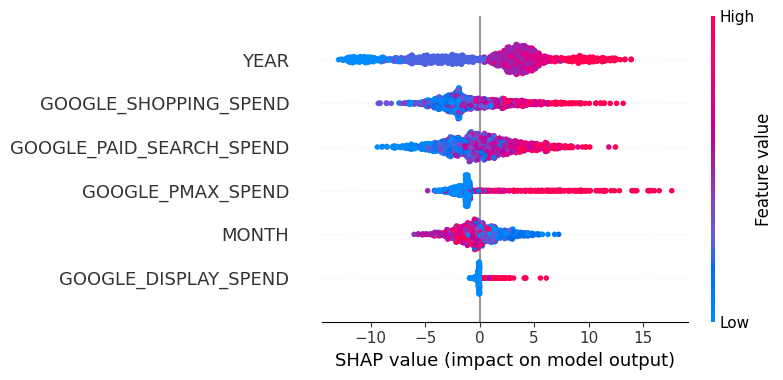

In [367]:
shap.summary_plot(
    shap_values,
    X
)

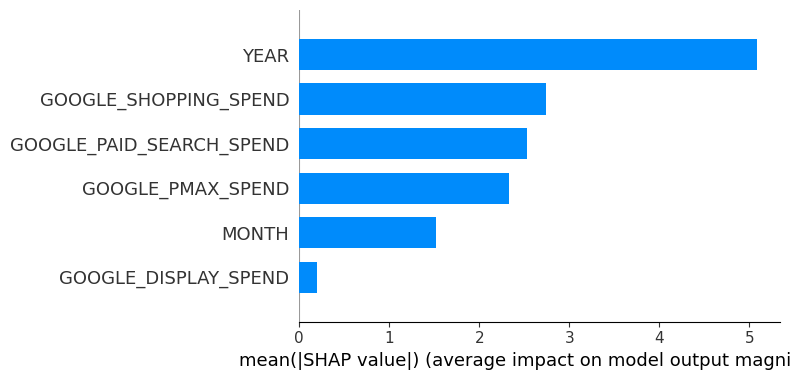

In [368]:
shap.summary_plot(
    shap_values,
    X,
    plot_type="bar"
)

### Report Interpretation

SHAP analysis was conducted using a Random Forest surrogate model trained on the same variables used in the Meridian analysis. The SHAP values quantify the contribution of each feature to predicted purchases. Features with larger absolute SHAP values exert greater influence on model predictions, providing an interpretable ranking of marketing drivers.

# 7. Budget Optimization

#### Budget optimization identifies how advertising spend can be reallocated across marketing channels to maximize purchases while respecting the defined budget constraints.

## 7.1 Initialize the Budget Optimizer

In [369]:
from meridian.analysis.optimizer import BudgetOptimizer

optimizer = BudgetOptimizer(meridian=mmm)

## 7.2 Define Helper Functions

In [370]:
# ============================================================
# Marketing Investment Scenario Simulator
# ============================================================

import numpy as np

def run_scenario(
    scenario_name,
    budget,
    pct_of_spend,
    optimizer,
    use_kpi=True,
):
    """
    Runs a Meridian budget optimization scenario.
    """

    scenario = optimizer.optimize(
        budget=budget,
        pct_of_spend=pct_of_spend,
        fixed_budget=True,
        use_posterior=True,
        use_kpi=use_kpi
    )

    print("=" * 60)
    print(scenario_name)
    print("=" * 60)
    print(f"Budget: {budget:,.2f}")
    print("Allocation:")

    for channel, pct in zip(
        scenario.optimized_data.channel.values,
        scenario.optimized_data["pct_of_spend"].values
    ):
        print(f"{channel:20s}: {pct*100:.2f}%")

    scenario.plot_budget_allocation()

    return scenario

### Interpretation

A reusable helper function is defined to automate budget optimization across multiple scenarios. The function runs the optimization, displays the recommended budget allocation, visualizes the allocation using a chart, and returns the optimization results for further analysis.

## 7.3 Historical Budget Optimization

In [371]:
results = optimizer.optimize(
    fixed_budget=True,
    use_posterior=True,
    use_kpi=True
)

results

OptimizationResults(analyzer=<meridian.analysis.analyzer.Analyzer object at 0x35181bcb0>, spend_ratio=<xarray.DataArray 'non_optimized' (channel: 4)> Size: 32B
array([1.0002711 , 1.00016764, 1.0002133 , 1.00808145])
Coordinates:
  * channel  (channel) <U18 288B 'Google Paid Search' ... 'Google Display', spend_bounds=(array([0.7]), array([1.3])), _nonoptimized_data=<xarray.Dataset> Size: 832B
Dimensions:              (channel: 4, metric: 4)
Coordinates:
  * channel              (channel) object 32B 'Google Paid Search' ... 'Googl...
  * metric               (metric) <U6 96B 'mean' 'median' 'ci_lo' 'ci_hi'
Data variables:
    spend                (channel) float64 32B 1.492e+05 1.994e+05 ... 1.2e+03
    pct_of_spend         (channel) float64 32B 0.3041 0.4064 0.2871 0.002445
    incremental_outcome  (channel, metric) float64 128B 3.502e+04 ... 90.38
    effectiveness        (channel, metric) float64 128B 0.3771 ... 0.00543
    roi                  (channel, metric) float64 128B 0.2347 ..

In [372]:
results.plot_budget_allocation()

alt.Chart(...)

In [373]:
results.plot_spend_delta()

alt.LayerChart(...)

In [374]:
results.plot_incremental_outcome_delta()

alt.LayerChart(...)

In [375]:
results.plot_response_curves()

alt.FacetChart(...)

In [376]:
results.output_optimization_summary(
    filename="budget_optimization.html",
    filepath="."
)

In [377]:
historical_budget = float(results.nonoptimized_data["spend"].sum())

print(f"Historical Budget: {historical_budget:,.2f}")

Historical Budget: 490,700.00


## 7.4 Scenario 1 – Increase Total Budget by 20%

In [378]:
scenario1 = optimizer.optimize(
    budget=historical_budget * 1.20,
    fixed_budget=True,
    use_posterior=True,
    use_kpi=True
)

scenario1.plot_budget_allocation()

alt.Chart(...)

In [379]:
scenario1.optimized_data

<xarray.Dataset> Size: 832B
Dimensions:              (channel: 4, metric: 4)
Coordinates:
  * channel              (channel) object 32B 'Google Paid Search' ... 'Googl...
  * metric               (metric) <U6 96B 'mean' 'median' 'ci_lo' 'ci_hi'
Data variables:
    spend                (channel) float64 32B 2.327e+05 2.367e+05 ... 1e+03
    pct_of_spend         (channel) float64 32B 0.3952 0.402 0.2011 0.001698
    incremental_outcome  (channel, metric) float64 128B 4.15e+04 ... 85.31
    effectiveness        (channel, metric) float64 128B 0.2865 ... 0.006151
    roi                  (channel, metric) float64 128B 0.1783 ... 0.08531
    mroi                 (channel, metric) float64 128B 0.06 0.05966 ... 0.02555
    cpik                 (channel, metric) float64 128B 5.898 5.908 ... 122.4
Attributes:
    start_date:                 2019-08-16
    end_date:                   2023-06-15
    budget:                     588800.0
    profit:                     -539623.5
    total_incremental_outcome:  49176.48
    total_roi:                  0.08351984
    total_cpik:                 12.410456657409668
    is_revenue_kpi:             False
    confidence_level:           0.9
    use_historical_budget:      False
    fixed_budget:               True

In [380]:
results.nonoptimized_data["pct_of_spend"].values

array([0.30405543, 0.40635826, 0.28714082, 0.00244549])

In [381]:
results.nonoptimized_data["channel"].values

array(['Google Paid Search', 'Google Shopping', 'Google PMAX',
       'Google Display'], dtype=object)

In [382]:
import numpy as np

current_pct = results.nonoptimized_data["pct_of_spend"].values

channels = results.nonoptimized_data["channel"].values

print(channels)
print(current_pct)

['Google Paid Search' 'Google Shopping' 'Google PMAX' 'Google Display']
[0.30405543 0.40635826 0.28714082 0.00244549]


In [383]:
scenario2_pct = current_pct.copy()

# Increase Google Paid Search by 50%
scenario2_pct[0] *= 1.50

# Normalize so allocations sum to 100%
scenario2_pct = scenario2_pct / scenario2_pct.sum()

print(scenario2_pct)

[0.39589598 0.35273306 0.24924819 0.00212277]


## 7.5 Scenario 2 – Increase Paid Search Budget by 50%

In [384]:
scenario2 = run_scenario(
    scenario_name="Scenario 2 (+50% Paid Search)",
    budget=historical_budget,
    pct_of_spend=scenario2_pct,
    optimizer=optimizer
)

Scenario 2 (+50% Paid Search)
Budget: 490,700.00
Allocation:
Google Paid Search  : 51.48%
Google Shopping     : 30.94%
Google PMAX         : 17.44%
Google Display      : 0.14%


## 7.6 Scenario 3 – Reduce Saturated Channel Spending

In [385]:
scenario3_pct = current_pct.copy()

# Reduce saturated channels
scenario3_pct[2] *= 0.70   # Google PMAX
scenario3_pct[3] *= 0.70   # Google Display

# Normalize
scenario3_pct = scenario3_pct / scenario3_pct.sum()

print("Scenario 3 Allocation")
for c, p in zip(channels, scenario3_pct):
    print(f"{c:20s}: {p:.2%}")

Scenario 3 Allocation
Google Paid Search  : 33.30%
Google Shopping     : 44.50%
Google PMAX         : 22.01%
Google Display      : 0.19%


In [386]:
scenario3 = run_scenario(
    scenario_name="Scenario 3 (-30% Saturated Channels)",
    budget=historical_budget,
    pct_of_spend=scenario3_pct,
    optimizer=optimizer
)

Scenario 3 (-30% Saturated Channels)
Budget: 490,700.00
Allocation:
Google Paid Search  : 43.29%
Google Shopping     : 40.43%
Google PMAX         : 16.14%
Google Display      : 0.14%


## 7.7 Scenario 4 – Random Budget Redistribution

In [387]:
np.random.seed(123)

scenario4_pct = current_pct.copy()

chosen = np.random.choice(
    len(scenario4_pct),
    size=2,
    replace=False
)

scenario4_pct[chosen] *= 1.10

scenario4_pct = scenario4_pct / scenario4_pct.sum()

print("Selected Channels:")
print(channels[chosen])

print("\nScenario 4 Allocation")
for c, p in zip(channels, scenario4_pct):
    print(f"{c:20s}: {p:.2%}")

Selected Channels:
['Google Display' 'Google Paid Search']

Scenario 4 Allocation
Google Paid Search  : 32.45%
Google Shopping     : 39.43%
Google PMAX         : 27.86%
Google Display      : 0.26%


In [388]:
scenario4 = run_scenario(
    scenario_name="Scenario 4 (+10% Random Half)",
    budget=historical_budget,
    pct_of_spend=scenario4_pct,
    optimizer=optimizer
)

Scenario 4 (+10% Random Half)
Budget: 490,700.00
Allocation:
Google Paid Search  : 42.18%
Google Shopping     : 38.13%
Google PMAX         : 19.50%
Google Display      : 0.18%


In [389]:
scenario1.optimized_data

<xarray.Dataset> Size: 832B
Dimensions:              (channel: 4, metric: 4)
Coordinates:
  * channel              (channel) object 32B 'Google Paid Search' ... 'Googl...
  * metric               (metric) <U6 96B 'mean' 'median' 'ci_lo' 'ci_hi'
Data variables:
    spend                (channel) float64 32B 2.327e+05 2.367e+05 ... 1e+03
    pct_of_spend         (channel) float64 32B 0.3952 0.402 0.2011 0.001698
    incremental_outcome  (channel, metric) float64 128B 4.15e+04 ... 85.31
    effectiveness        (channel, metric) float64 128B 0.2865 ... 0.006151
    roi                  (channel, metric) float64 128B 0.1783 ... 0.08531
    mroi                 (channel, metric) float64 128B 0.06 0.05966 ... 0.02555
    cpik                 (channel, metric) float64 128B 5.898 5.908 ... 122.4
Attributes:
    start_date:                 2019-08-16
    end_date:                   2023-06-15
    budget:                     588800.0
    profit:                     -539623.5
    total_incremental_outcome:  49176.48
    total_roi:                  0.08351984
    total_cpik:                 12.410456657409668
    is_revenue_kpi:             False
    confidence_level:           0.9
    use_historical_budget:      False
    fixed_budget:               True

In [390]:
list(scenario1.optimized_data.data_vars)

['spend',
 'pct_of_spend',
 'incremental_outcome',
 'effectiveness',
 'roi',
 'mroi',
 'cpik']

## 7.8 Scenario Comparison

In [391]:
import pandas as pd
import numpy as np

def summarize_scenario(name, scenario):
    data = scenario.optimized_data

    return {
        "Scenario": name,
        "Budget": round(float(data["spend"].sum()), 2),

        "Paid Search (%)": round(float(data["pct_of_spend"][0])*100,2),
        "Shopping (%)": round(float(data["pct_of_spend"][1])*100,2),
        "PMAX (%)": round(float(data["pct_of_spend"][2])*100,2),
        "Display (%)": round(float(data["pct_of_spend"][3])*100,2),

        "Predicted Purchases":
            round(float(data["incremental_outcome"].sel(metric="mean").sum()),2),

        "Average ROI":
            round(float(data["roi"].sel(metric="mean").mean()),3),

        "Average mROI":
            round(float(data["mroi"].sel(metric="mean").mean()),3)
    }

comparison = pd.DataFrame([
    summarize_scenario("Scenario 1 (+20%)", scenario1),
    summarize_scenario("Scenario 2 (+50% Paid Search)", scenario2),
    summarize_scenario("Scenario 3 (-30% Saturated)", scenario3),
    summarize_scenario("Scenario 4 (+10% Random)", scenario4),
])

comparison

,Scenario,Budget,Paid Search (%),Shopping (%),PMAX (%),Display (%),Predicted Purchases,Average ROI,Average mROI
0,Scenario 1 (+20%),588800.0,39.52,40.20,20.11,0.17,49176.48,0.063,0.024
1,Scenario 2 (+50% Paid Search),490700.0,51.48,30.94,17.44,0.14,48523.58,0.065,0.026
2,Scenario 3 (-30% Saturated),490700.0,43.29,40.43,16.14,0.14,46777.51,0.069,0.028
3,Scenario 4 (+10% Random),490700.0,42.18,38.13,19.50,0.18,46475.62,0.068,0.028
